In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as f

In [2]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [3]:
# designate landscape to load

lscape_name_notxt = 'dipplane90_fee15_ini_6_9_24_fee_40_7_13_17_A_1strongxvyvss3'

img_folder = 'imgs/' + lscape_name_notxt + '/'

In [4]:
import numpy as np
import json

with np.load(img_folder + 'Xy_' + lscape_name_notxt + '.npz' ) as data:
    # print("Available keys:", data.files) # uncomment to see specific file names
    topo_anis_X = data['topo_anis']
    strength_fail_stress_y = data['strength_fail_stress']

print(topo_anis_X.shape)
print(strength_fail_stress_y.shape)

with open(img_folder + 'Xy_' + lscape_name_notxt + '_meta.json') as f:
    meta = json.load(f)

feature_names_topo = meta['topo_anis_features']
feature_names_failstren = meta['strength_fail_stress_features']
print(feature_names_topo)
print(feature_names_failstren)

(76, 76, 12)
(76, 76, 6)
['z', 'slope', 'sin_aspect', 'cos_aspect', 'prof_curv', 'plan_curv', 'evaphi_1', 'evamag_1', 'evaphi_5', 'evamag_5', 'evaphi_10', 'evamag_10']
['tenstren', 'tenfail', 'cohesion', 'shearfail', 'diffstress', 'strengthstress']


In [6]:
# extract and flatten features
h, w, n_feat = topo_anis_X.shape
X_flat = topo_anis_X.reshape(-1, n_feat)

In [7]:
# extract cohesion and create binary label
cohesion_flat = strength_fail_stress_y[:, :, 2].reshape(-1)  # index 2 = cohesion
threshold = 100000.5
y_weak = (cohesion_flat <= threshold).astype(int)

In [8]:
print(f"weak plane pixels: {y_weak.sum()} ({y_weak.mean()*100:.1f}%)")
print(f"non-weak pixels: {(y_weak==0).sum()} ({(1-y_weak.mean())*100:.1f}%)")

weak plane pixels: 349 (6.0%)
non-weak pixels: 5427 (94.0%)


In [9]:
# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

In [10]:
# stratified split to preserve weak plane ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_weak, test_size=0.2,
    stratify=y_weak, random_state=42)

In [11]:
print(f"\ntrain weak fraction: {y_train.mean():.4f}")
print(f"test weak fraction:  {y_test.mean():.4f}")


train weak fraction: 0.0604
test weak fraction:  0.0606


In [12]:
# train classifier
clf = MLPClassifier(hidden_layer_sizes=(64, 64, 64, 32),
                    random_state=42, max_iter=2000)
clf.fit(X_train, y_train)

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True
,random_state,42


In [13]:
# evaluate
y_pred = clf.predict(X_test)

In [14]:
print("\nclassification report:")
print(classification_report(y_test, y_pred,
      target_names=['non-weak', 'weak plane']))
print("confusion matrix:")
print(confusion_matrix(y_test, y_pred))


classification report:
              precision    recall  f1-score   support

    non-weak       0.95      0.96      0.95      1086
  weak plane       0.24      0.20      0.22        70

    accuracy                           0.91      1156
   macro avg       0.59      0.58      0.59      1156
weighted avg       0.91      0.91      0.91      1156

confusion matrix:
[[1041   45]
 [  56   14]]


In [15]:
# undersample to account for greater non-weak numbers

In [64]:
# indices of weak class
weak_idx = np.where(y_weak == 1)[0]
nonweak_idx = np.where(y_weak == 0)[0]

print(f"weak: {len(weak_idx)}, non-weak: {len(nonweak_idx)}")

# subsample non-weak to e.g. 3:1 ratio
target_ratio = 3 # non-weak : weak
n_nonweak_keep = len(weak_idx) * target_ratio

np.random.seed(42)
nonweak_keep = np.random.choice(nonweak_idx,
                                size=n_nonweak_keep,
                                replace=False)

# combine and shuffle
keep_idx = np.concatenate([weak_idx, nonweak_keep])
np.random.shuffle(keep_idx)

X_balanced = X_scaled[keep_idx]
y_balanced = y_weak[keep_idx]

print(f"balanced dataset: {len(y_balanced)} pixels")
print(f"weak fraction: {y_balanced.mean():.3f}")

weak: 349, non-weak: 5427
balanced dataset: 1396 pixels
weak fraction: 0.250


In [65]:
# train/test split the balanced datasets

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2,
    stratify=y_balanced, random_state=42)

In [66]:
print(f"\ntrain weak fraction: {y_train_bal.mean():.4f}")
print(f"test weak fraction:  {y_test_bal.mean():.4f}")


train weak fraction: 0.2500
test weak fraction:  0.2500


In [67]:
# train classifier
clf_balanced = MLPClassifier(hidden_layer_sizes=(64, 64, 64, 32),
                    random_state=42, max_iter=2000)
clf_balanced.fit(X_train_bal, y_train_bal)

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True
,random_state,42


In [68]:
# evaluate
y_pred_bal = clf_balanced.predict(X_test_bal)

In [69]:
print("\nclassification report:")
print(classification_report(y_test_bal, y_pred_bal,
      target_names=['non-weak', 'weak plane']))
print("confusion matrix:")
print(confusion_matrix(y_test_bal, y_pred_bal))


classification report:
              precision    recall  f1-score   support

    non-weak       0.83      0.85      0.84       210
  weak plane       0.52      0.49      0.50        70

    accuracy                           0.76       280
   macro avg       0.68      0.67      0.67       280
weighted avg       0.76      0.76      0.76       280

confusion matrix:
[[179  31]
 [ 36  34]]


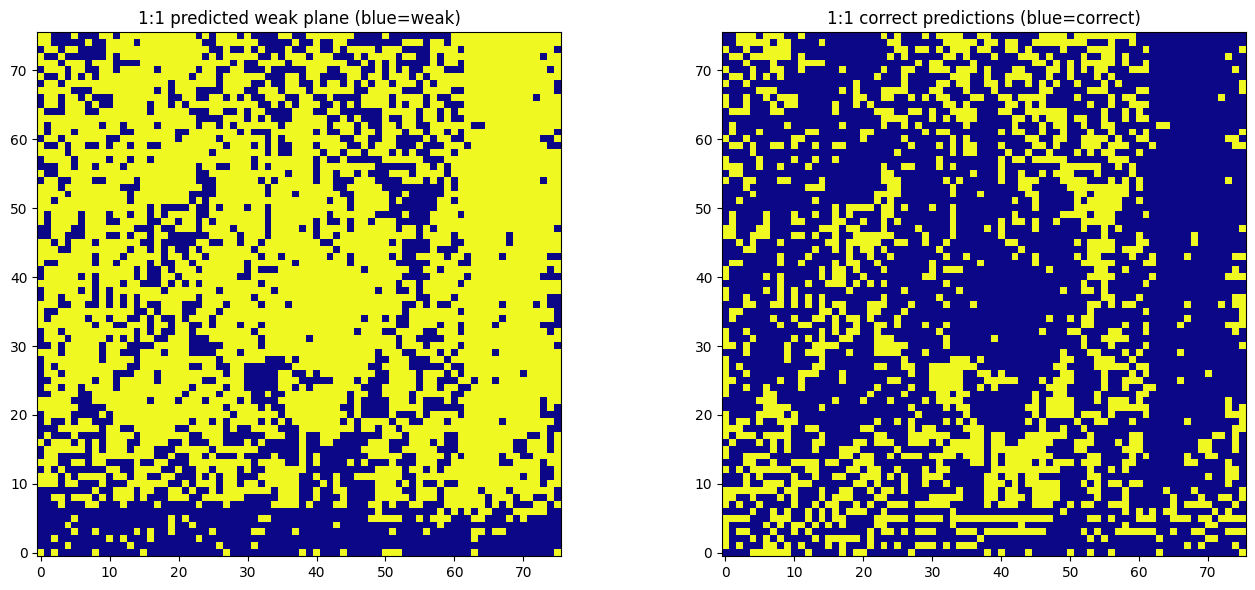

In [57]:
# plot predictions spatially

import matplotlib.pyplot as plt

bal_tag = f'balancedMLP_{target_ratio}to1_'

# get predictions on full dataset
y_pred_full = clf_balanced.predict(X_scaled)
y_true_full = y_weak

correct = (y_pred_full == y_true_full).astype(float)
pred_grid = y_pred_full.reshape(h, w)
correct_grid = correct.reshape(h, w)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(pred_grid, cmap='plasma_r', origin='lower')
axes[0].set_title(f'{target_ratio}:1 predicted weak plane (blue=weak)')

axes[1].imshow(correct_grid, cmap='plasma_r', origin='lower')
axes[1].set_title(f'{target_ratio}:1 correct predictions (blue=correct)')

plt.tight_layout()
#plt.savefig(img_folder + bal_tag + lscape_name_notxt + '.png')
plt.show()